# Orientation Validation — pre-DRR Volumes

**Goal:** Check every pre-processed knee volume in `data/interim/predrr/` (58 healthy + 14 fractured, all 256³) and flag the ones that are **upside-down** (femur/superior at the *bottom* instead of the top). Standing-upright = femur on top, tibia/fibula on the bottom.

**Scope:** This notebook is **inspection-only**. It *flags* flipped cases and lets you visually confirm them — it does **not** flip or re-save any volume. The actual correction will be merged into `predrr_preprocessing.ipynb` later. The deliverable here is a trustworthy list of flipped case IDs.

### What the investigation found

- **All 72 volumes have identical affines** — axcodes `('L','P','S')`, positive determinant. So the flip is **not** in the NIfTI metadata; the affine always claims superior is at the high-index end of axis 2 (`k`, the S–I axis). The flip lives in the **voxel data**: for the bad cases the femur physically sits at the low-`k` (inferior) end, contradicting the affine. → *affine-based detection is impossible.*
- A simple bone-mass ratio (superior vs inferior) is **too noisy** to separate them.
- A **connected-component heuristic works cleanly**: count bone blobs per axial slice at each end of the volume.
  - Femur end → **1 blob**; tibia + fibula end → **2 blobs**.
  - **Upright:** superior=1, inferior=2.  **Flipped:** superior=2, inferior=1.  Anything else → **ambiguous** (check by eye).

### Convention used for display

Volumes are **LPS**: axis0 = L–R (X), axis1 = A–P (Y), axis2 = S–I (Z), high-`k` = superior. Every panel below is drawn with **superior at the TOP**. The convention is sanity-checked against a known-upright reference (`VSD_002_Right`) before the grid is trusted.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import glob

import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage

# --- Paths -------------------------------------------------------------------
# Notebook lives in TestProject/notebooks/pre-processing/ ; data is two levels up.
PREDRR = (Path.cwd() / ".." / ".." / "data" / "interim" / "predrr").resolve()
assert PREDRR.is_dir(), f"predrr dir not found: {PREDRR}"

# --- Heuristic / display constants (tune here if a case misbehaves) ----------
BONE_THR   = 0.45   # normalized-intensity threshold for "bone"
MIN_AREA   = 30     # min voxels for a 2D component to count as a blob
END_FRAC   = 0.25   # use the top/bottom quarter of k as the "superior"/"inferior" ends
REFERENCE  = "VSD_002_Right"  # known-upright case used to validate the display convention

# --- Gather the 72 volumes ---------------------------------------------------
files = sorted(glob.glob(str(PREDRR / "**" / "*.nii.gz"), recursive=True))
cases = []
for f in files:
    p = Path(f)
    cases.append({
        "case": p.stem.replace(".nii", ""),       # e.g. VSD_001_Left, Case3_PartLeft
        "dataset": p.parent.name,                  # healthy | fractured
        "path": p,
    })
df_files = pd.DataFrame(cases)
print(f"Found {len(df_files)} volumes")
print(df_files["dataset"].value_counts().to_string())


Found 72 volumes
dataset
healthy      58
fractured    14


In [2]:
# --- Display + heuristic helpers --------------------------------------------
def coronal(arr):
    """Mid coronal slice, superior at TOP. arr is LPS (X,Y,Z)."""
    sl = arr[:, arr.shape[1] // 2, :]      # (X, Z)
    return sl.T[::-1]                       # rows = Z (high->low top->bottom), cols = X

def sagittal(arr):
    """Mid sagittal slice, superior at TOP."""
    sl = arr[arr.shape[0] // 2, :, :]      # (Y, Z)
    return sl.T[::-1]                       # rows = Z, cols = Y

def _blobs_in_axial(sl2d):
    """Number of bone components (area > MIN_AREA) in one axial slice."""
    mask = ndimage.binary_opening(sl2d > BONE_THR, iterations=1)
    lab, n = ndimage.label(mask)
    if n == 0:
        return 0
    sizes = ndimage.sum(np.ones_like(lab), lab, range(1, n + 1))
    return int((sizes > MIN_AREA).sum())

def end_blob_counts(arr):
    """Median axial blob count in the superior (high-k) and inferior (low-k) ends."""
    k = arr.shape[2]
    e = max(1, int(round(k * END_FRAC)))
    sup = np.median([_blobs_in_axial(arr[:, :, kk]) for kk in range(k - e, k)])
    inf = np.median([_blobs_in_axial(arr[:, :, kk]) for kk in range(0, e)])
    return float(sup), float(inf)

def verdict_of(sup, inf):
    if sup <= 1 and inf >= 2:
        return "UPRIGHT"
    if sup >= 2 and inf <= 1:
        return "FLIPPED"
    return "AMBIGUOUS"

VERDICT_COLOR = {"UPRIGHT": "green", "FLIPPED": "red", "AMBIGUOUS": "darkorange"}


In [3]:
# --- Scan all 72 volumes -----------------------------------------------------
# One pass: compute the blob heuristic AND cache mid-slices (cheap) for the grids.
records, slices = [], {}
for r in df_files.itertuples():
    arr = nib.load(str(r.path)).get_fdata().astype(np.float32)
    sup, inf = end_blob_counts(arr)
    records.append({
        "case": r.case, "dataset": r.dataset,
        "sup_blobs": sup, "inf_blobs": inf, "verdict": verdict_of(sup, inf),
    })
    slices[r.case] = {"coronal": coronal(arr), "sagittal": sagittal(arr), "path": r.path}

df = df_files[["case", "dataset"]].merge(pd.DataFrame(records), on=["case", "dataset"])

# sort problems first
order = {"FLIPPED": 0, "AMBIGUOUS": 1, "UPRIGHT": 2}
df = df.sort_values(by=["verdict", "dataset", "case"], key=lambda s: s.map(order).fillna(s)).reset_index(drop=True)

print(df["verdict"].value_counts().to_string())
print("\nFlagged (FLIPPED / AMBIGUOUS):")
print(df[df.verdict != "UPRIGHT"][["case", "dataset", "sup_blobs", "inf_blobs", "verdict"]].to_string(index=False))
df


verdict
UPRIGHT      69
AMBIGUOUS     3

Flagged (FLIPPED / AMBIGUOUS):
            case   dataset  sup_blobs  inf_blobs   verdict
Case14_PartRight fractured        1.5        2.0 AMBIGUOUS
    VSD_016_Left   healthy        1.5        2.0 AMBIGUOUS
   VSD_016_Right   healthy        2.0        2.0 AMBIGUOUS


,case,dataset,sup_blobs,inf_blobs,verdict
0,Case14_PartRight,fractured,1.5,2.0,AMBIGUOUS
1,VSD_016_Left,healthy,1.5,2.0,AMBIGUOUS
2,VSD_016_Right,healthy,2.0,2.0,AMBIGUOUS
3,Case11_PartRight,fractured,1.0,2.0,UPRIGHT
4,Case12_PartRight,fractured,1.0,2.0,UPRIGHT
...,...,...,...,...,...
67,VSD_z063_Left,healthy,1.0,2.0,UPRIGHT
68,VSD_z064_Left,healthy,1.0,3.0,UPRIGHT
69,VSD_z064_Right,healthy,1.0,3.0,UPRIGHT
70,VSD_z066_Left,healthy,1.0,2.0,UPRIGHT


## 1. Validate the display convention

Before trusting any grid, confirm the reference case shows the **femur on top** (single thick bone) and the **tibia+fibula on the bottom** (two bones / a thinner one to the side). If this looks right, "superior at top" is correct for every other panel.

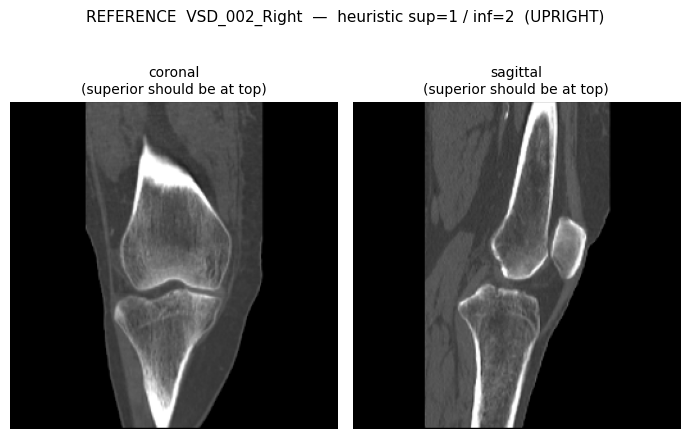

In [4]:
# Reference panel — should read femur(top) / tibia+fibula(bottom)
ref = slices[REFERENCE]
ref_row = df[df.case == REFERENCE].iloc[0]
fig, ax = plt.subplots(1, 2, figsize=(7, 5))
for a, (name, img) in zip(ax, [("coronal", ref["coronal"]), ("sagittal", ref["sagittal"])]):
    a.imshow(img, cmap="gray", vmin=0, vmax=1, aspect="equal")
    a.set_title(f"{name}\n(superior should be at top)", fontsize=10)
    a.axis("off")
fig.suptitle(f"REFERENCE  {REFERENCE}  —  heuristic sup={ref_row.sup_blobs:.0f} / inf={ref_row.inf_blobs:.0f}  ({ref_row.verdict})",
             fontsize=11)
plt.tight_layout(); plt.show()


## 2. Montage grid — every volume

Coronal mid-slice of all 72 volumes, **superior at top**. Title colour = heuristic verdict: <span style="color:green">**green = upright**</span>, <span style="color:red">**red = flipped**</span>, <span style="color:darkorange">**orange = ambiguous**</span>. Scan for any panel whose anatomy disagrees with its colour — a green panel showing femur-at-bottom (or a red one showing femur-at-top) is a heuristic miss to correct by eye in the final list.

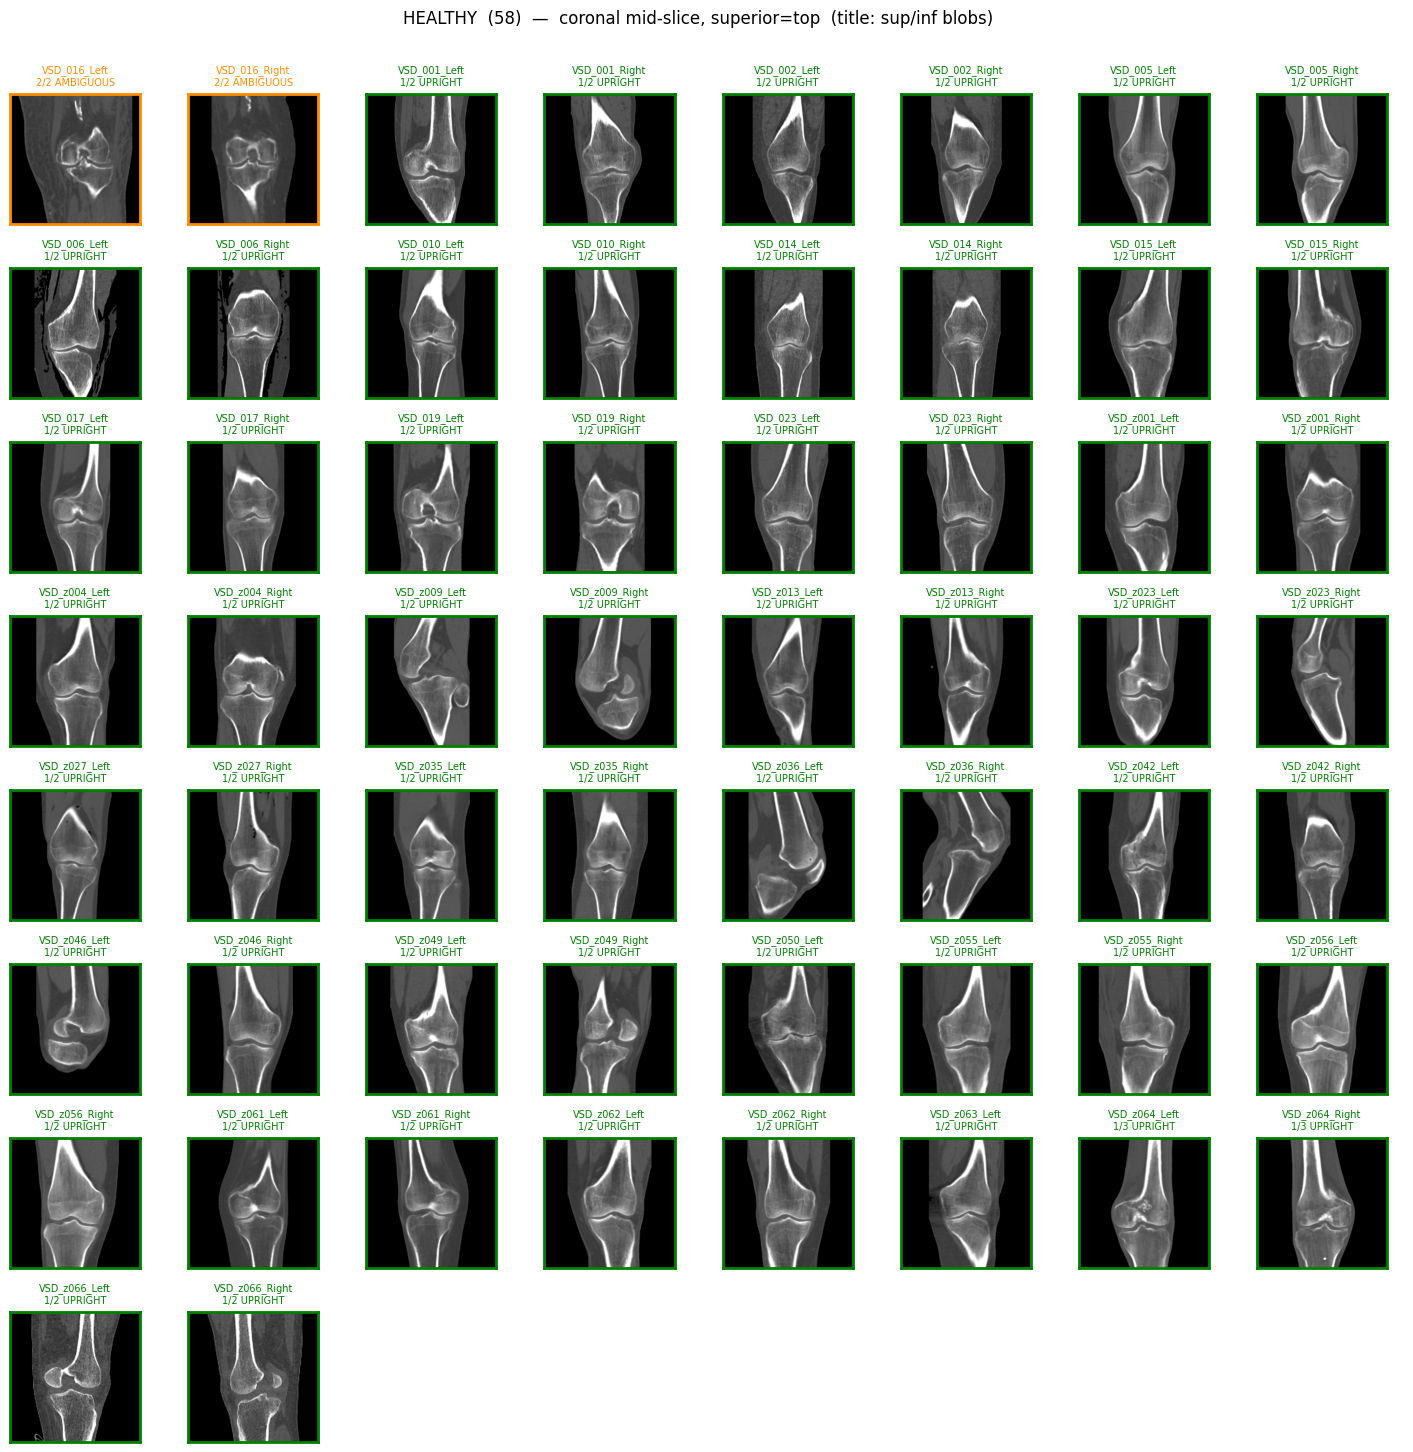

In [5]:
def montage(dataset, ncols=8, panel=1.8):
    """Grid of coronal mid-slices for one dataset, titled + bordered by verdict."""
    sub = df[df.dataset == dataset]
    n = len(sub); nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * panel, nrows * panel))
    axes = np.atleast_2d(axes).ravel()
    for ax, row in zip(axes, sub.itertuples()):
        c = VERDICT_COLOR[row.verdict]
        ax.imshow(slices[row.case]["coronal"], cmap="gray", vmin=0, vmax=1, aspect="equal")
        ax.set_title(f"{row.case}\n{row.sup_blobs:.0f}/{row.inf_blobs:.0f} {row.verdict}",
                     fontsize=7, color=c)
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_color(c); s.set_linewidth(2)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(f"{dataset.upper()}  ({n})  —  coronal mid-slice, superior=top  (title: sup/inf blobs)",
                 fontsize=12, y=1.005)
    plt.tight_layout(); plt.show()

montage("healthy")


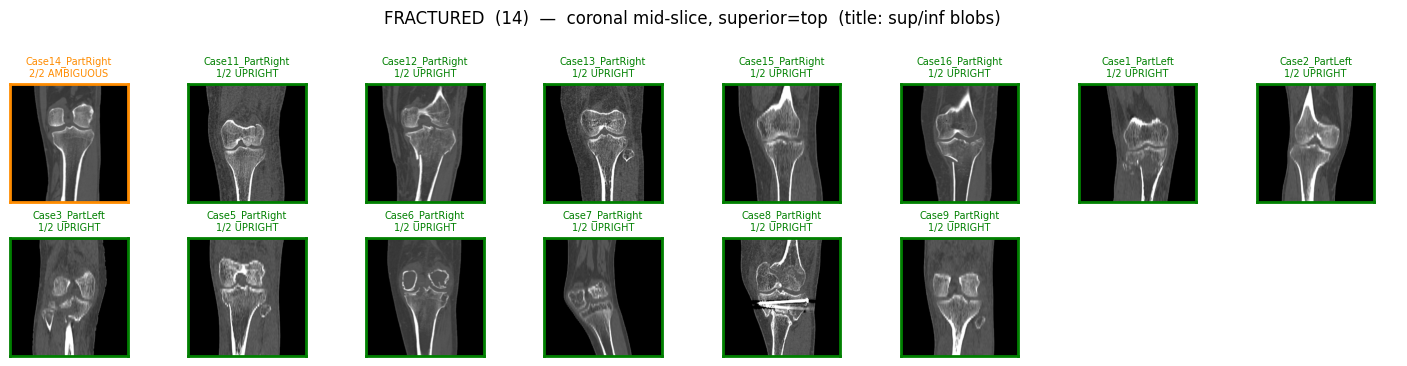

In [6]:
montage("fractured")


## 3. Detailed sanity check — flagged cases

Full-size views of every **FLIPPED** and **AMBIGUOUS** case so you can confirm by eye. For each: coronal + sagittal (superior=top), plus an axial slice from each end so you can literally count the bones (femur end = 1 blob, tibia+fibula end = 2). The reference row is repeated at the top for comparison.

3 flagged case(s): ['Case14_PartRight', 'VSD_016_Left', 'VSD_016_Right']


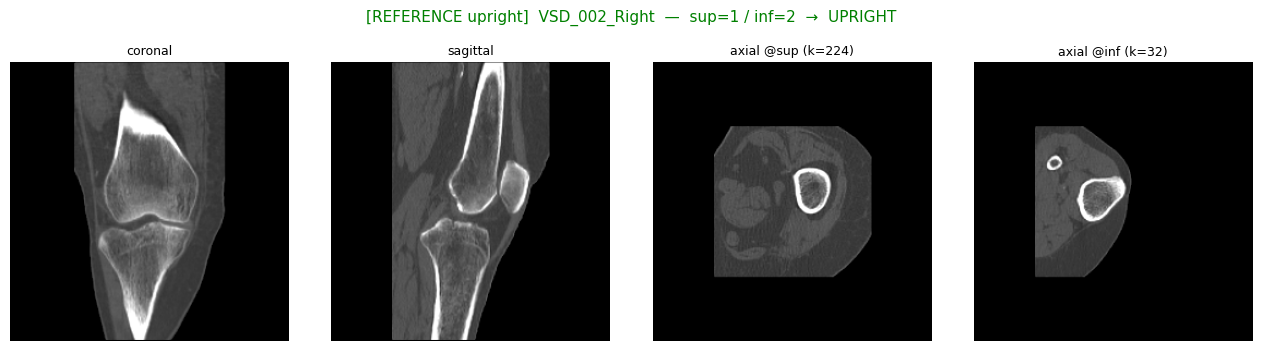

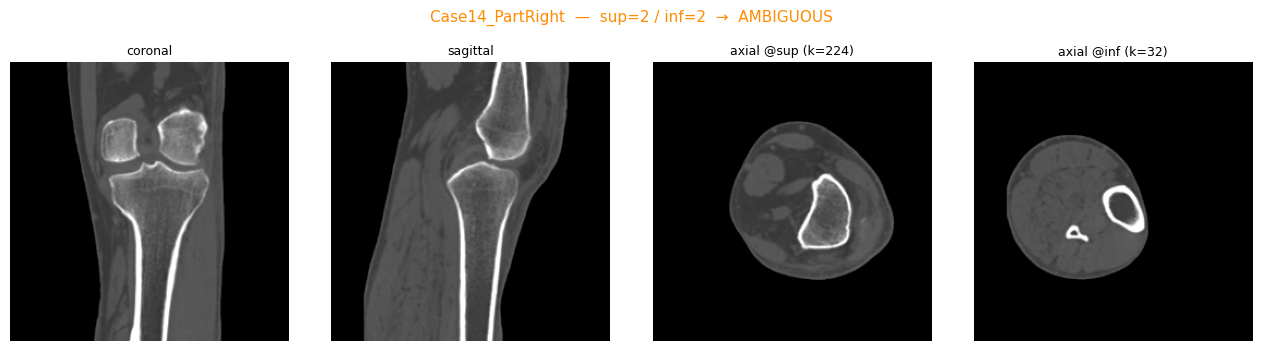

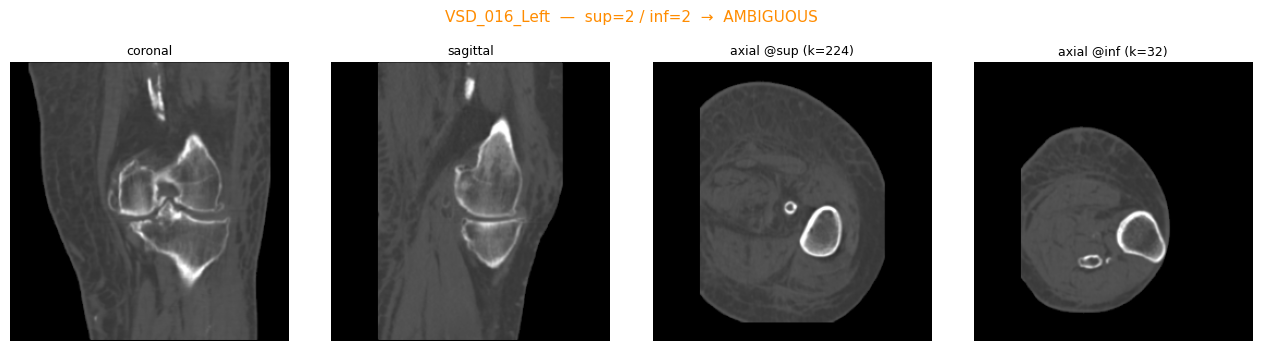

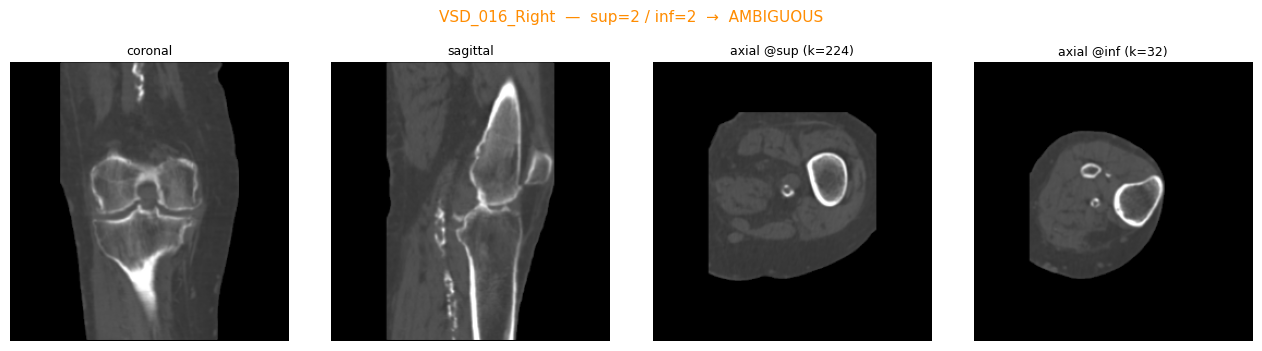

In [7]:
def detail_row(case, tag=""):
    """One row: coronal | sagittal | axial@superior-end | axial@inferior-end."""
    arr = nib.load(str(slices[case]["path"])).get_fdata().astype(np.float32)
    k = arr.shape[2]; e = int(round(k * END_FRAC))
    row = df[df.case == case].iloc[0]
    c = VERDICT_COLOR[row.verdict]
    panels = [
        ("coronal",          coronal(arr)),
        ("sagittal",         sagittal(arr)),
        (f"axial @sup (k={k-e//2})", arr[:, :, k - e // 2]),   # top-end cross-section
        (f"axial @inf (k={e//2})",   arr[:, :, e // 2]),       # bottom-end cross-section
    ]
    fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
    for a, (name, img) in zip(axes, panels):
        a.imshow(img, cmap="gray", vmin=0, vmax=1, aspect="equal")
        a.set_title(name, fontsize=9); a.axis("off")
    fig.suptitle(f"{tag}{case}  —  sup={row.sup_blobs:.0f} / inf={row.inf_blobs:.0f}  →  {row.verdict}",
                 fontsize=11, color=c, y=1.02)
    plt.tight_layout(); plt.show()

flagged = df[df.verdict != "UPRIGHT"]["case"].tolist()
print(f"{len(flagged)} flagged case(s):", flagged)

detail_row(REFERENCE, tag="[REFERENCE upright]  ")
for case in flagged:
    detail_row(case)


## 4. Confirmed result

`confirmed_flipped` is pre-filled from the heuristic. **Edit it** after your visual review — add any case the grid showed upside-down that the heuristic missed, remove any false alarm. This list is the deliverable to feed into the flip step in `predrr_preprocessing.ipynb` later. Running the cell also writes a small `orientation_validation_report.csv` next to the volumes (metadata only — **no volume data is modified**).

In [8]:
# Pre-filled from the heuristic — EDIT after visual review.
confirmed_flipped = df[df.verdict == "FLIPPED"]["case"].tolist()

# (review the AMBIGUOUS cases by eye and move any true flips into the list above)
ambiguous = df[df.verdict == "AMBIGUOUS"]["case"].tolist()

print(f"confirmed_flipped ({len(confirmed_flipped)}):")
for c in confirmed_flipped:
    print("   ", c)
print(f"\nambiguous to review by eye ({len(ambiguous)}):", ambiguous)

# Write metadata-only report for the later predrr_preprocessing flip step.
report = df[["case", "dataset", "sup_blobs", "inf_blobs", "verdict"]].copy()
report["confirmed_flipped"] = report["case"].isin(confirmed_flipped)
report_path = PREDRR / "orientation_validation_report.csv"
report.to_csv(report_path, index=False)
print(f"\nReport written: {report_path}")


confirmed_flipped (0):

ambiguous to review by eye (3): ['Case14_PartRight', 'VSD_016_Left', 'VSD_016_Right']

Report written: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\interim\predrr\orientation_validation_report.csv
